# Data Binning

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt


In [3]:
df = sns.load_dataset("titanic")

In [4]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
df.drop("deck", axis=1, inplace=True)

In [6]:
df["age"] = df["age"].fillna(df["age"].median(), inplace=True)

/tmp/ipykernel_11115/1065752152.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["age"] = df["age"].fillna(df["age"].median(), inplace=True)


In [7]:
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

In [8]:
df["embark_town"] = df["embark_town"].fillna(df["embark_town"].mode()[0]) 

In [9]:
df.isna().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

### What's Data Binning?
----------------------------------------------------
- To Divide Numerical data into different groups based on ranges to make a sense out of it

In [10]:
df.age.min()

np.float64(0.42)

In [11]:
df.age.max()

np.float64(80.0)

<Axes: xlabel='age', ylabel='Count'>

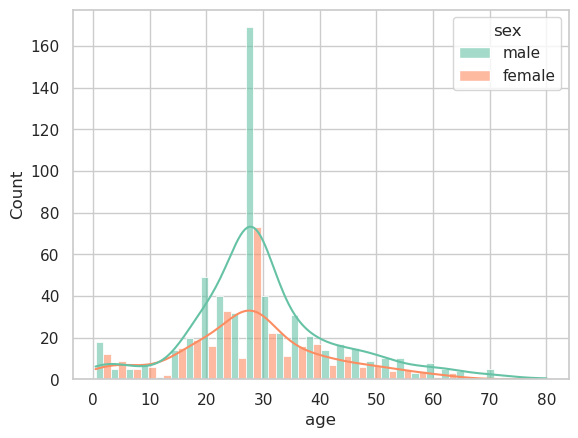

In [12]:
sns.set_theme(style="whitegrid")

sns.histplot(
    data=df,
    x="age",
    hue="sex",
    palette="Set2",
    kde=True,
    alpha=0.6,
    bins=30,
    multiple="dodge"
)

Histogram shows Distribution of data

### Binning of age column into 7 categories

In [13]:
bins = [0, 1, 5, 12, 19, 30, 50, 80]
labels = ["Infants", "Toddlers", "Kids", "Teens", "Youngs", "Middle Aged", "Old"]
pd.cut(df["age"], bins=bins, labels=labels)

0           Youngs
1      Middle Aged
2           Youngs
3      Middle Aged
4      Middle Aged
          ...     
886         Youngs
887          Teens
888         Youngs
889         Youngs
890    Middle Aged
Name: age, Length: 891, dtype: category
Categories (7, str): ['Infants' < 'Toddlers' < 'Kids' < 'Teens' < 'Youngs' < 'Middle Aged' < 'Old']

In [14]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


## Feature Engineering:
-----------------------------------
- To add more columns on the bases of available columns

In [15]:
bins = [0, 1, 5, 12, 19, 30, 50, 80]
labels = ["Infants", "Toddlers", "Kids", "Teens", "Youngs", "Middle Aged", "Old"]
df["binned_ages"] = pd.cut(df["age"], bins=bins, labels=labels)

In [16]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,binned_ages
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,Youngs
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,Middle Aged
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,Youngs
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,Middle Aged
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,Middle Aged


In [17]:
df["binned_ages"].value_counts()

binned_ages
Youngs         422
Middle Aged    241
Teens           95
Old             64
Toddlers        30
Kids            25
Infants         14
Name: count, dtype: int64

### Renaming a column(s)

In [18]:
df.rename(columns={"binned_ages": "age_groups"}, inplace=True)

In [19]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,age_groups
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,Youngs
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,Middle Aged
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,Youngs
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,Middle Aged
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,Middle Aged


In [20]:
df.groupby(["survived", "class", "age_groups", "sex"]).size()

survived  class  age_groups   sex   
0         First  Toddlers     female     1
                 Teens        male       3
                 Youngs       female     1
                              male      26
                 Middle Aged  female     1
                                        ..
1         Third  Youngs       female    41
                              male      26
                 Middle Aged  female     6
                              male       9
                 Old          female     1
Length: 62, dtype: int64

In [21]:
df["class"].value_counts()

class
Third     491
First     216
Second    184
Name: count, dtype: int64

#### Filter Data based on rows criteria

In [24]:
df[df["class"] == "First"].value_counts()

survived  pclass  sex     age   sibsp  parch  fare     embarked  class  who    adult_male  embark_town  alive  alone  age_groups
1         1       male    28.0  0      0      35.5000  S         First  man    True        Southampton  yes    True   Youngs        2
0         1       male    28.0  0      0      27.7208  C         First  man    True        Cherbourg    no     True   Youngs        2
                          62.0  0      0      26.5500  S         First  man    True        Southampton  no     True   Old           2
1         1       female  24.0  0      0      69.3000  C         First  woman  False       Cherbourg    yes    True   Youngs        2
                  male    28.0  0      0      26.5500  S         First  man    True        Southampton  yes    True   Youngs        2
                                                                                                                                   ..
                          26.0  0      0      30.0000  C         Th

#### Select only those rows which paid more than 200 pounds

In [25]:
df[df["fare"] > 200]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,age_groups
27,0,1,male,19.0,3,2,263.0000,S,First,man,True,Southampton,no,False,Teens
88,1,1,female,23.0,3,2,263.0000,S,First,woman,False,Southampton,yes,False,Youngs
118,0,1,male,24.0,0,1,247.5208,C,First,man,True,Cherbourg,no,False,Youngs
258,1,1,female,35.0,0,0,512.3292,C,First,woman,False,Cherbourg,yes,True,Middle Aged
299,1,1,female,50.0,0,1,247.5208,C,First,woman,False,Cherbourg,yes,False,Middle Aged
311,1,1,female,18.0,2,2,262.3750,C,First,woman,False,Cherbourg,yes,False,Teens
341,1,1,female,24.0,3,2,263.0000,S,First,woman,False,Southampton,yes,False,Youngs
377,0,1,male,27.0,0,2,211.5000,C,First,man,True,Cherbourg,no,False,Youngs
380,1,1,female,42.0,0,0,227.5250,C,First,woman,False,Cherbourg,yes,True,Middle Aged
438,0,1,male,64.0,1,4,263.0000,S,First,man,True,Southampton,no,False,Old


In [35]:
counts = df[df["fare"] == 0]
print(f"Total number of passengers with £0 fare paid: {len(counts)}")
## Second method
print((df["fare"] == 0).sum())

Total number of passengers with £0 fare paid: 15
15


In [ ]:
sns.boxplot()

### How to add two filters

In [28]:
df[(df["fare"] > 70) & (df["class"] == "First")]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,age_groups
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,Middle Aged
27,0,1,male,19.0,3,2,263.0000,S,First,man,True,Southampton,no,False,Teens
31,1,1,female,28.0,1,0,146.5208,C,First,woman,False,Cherbourg,yes,False,Youngs
34,0,1,male,28.0,1,0,82.1708,C,First,man,True,Cherbourg,no,False,Youngs
52,1,1,female,49.0,1,0,76.7292,C,First,woman,False,Cherbourg,yes,False,Middle Aged
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
829,1,1,female,62.0,0,0,80.0000,S,First,woman,False,Southampton,yes,True,Old
835,1,1,female,39.0,1,1,83.1583,C,First,woman,False,Cherbourg,yes,False,Middle Aged
849,1,1,female,28.0,1,0,89.1042,C,First,woman,False,Cherbourg,yes,False,Youngs
856,1,1,female,45.0,1,1,164.8667,S,First,woman,False,Southampton,yes,False,Middle Aged
